In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.under_sampling import RandomUnderSampler
from tqdm import tqdm
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from src.utils.config import *

In [2]:
# Cargamos el dataset
df = pd.read_csv(RAW_DIR  / 'dataset_finalV2.csv')
df.head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
0,--PJHxphWEs.wav,/C/gun_explosion_a0a388e0,"[""/C/gun_explosion_a0a388e0""]",gun_explosion,"[""gun_explosion""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.11,2026-05-12 17:56:50
1,--aE2O5G5WE.wav,/C/gun_explosion_a0a388e0,"[""/C/gun_explosion_a0a388e0""]",gun_explosion,"[""gun_explosion""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.08,2026-05-12 12:27:49
2,-0DLPzsiXXE.wav,/C/instrument_music_b311b450,"[""/C/instrument_music_b311b450""]",instrument_music,"[""instrument_music""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:08
3,-0SdAVK79lg.wav,/C/instrument_music_b311b450,"[""/C/instrument_music_b311b450""]",instrument_music,"[""instrument_music""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 12:36:58
4,-11LhdJgBb8.wav,/C/instrument_music_b311b450,"[""/C/instrument_music_b311b450""]",instrument_music,"[""instrument_music""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,test,NaN,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:22


In [3]:
# Imprimimos el numero de filas
print(f"Número de filas en 'df': {len(df)}")

# Verificamos la cantidad de variables por tipos de datos en df que son los datos que vamos a aplicar en el EDA:
pd.Series.value_counts(df.dtypes)

Número de filas en 'df': 132384


str        11
float64     6
bool        3
Name: count, dtype: int64

In [4]:
# Obtenemos qué columnas tienen valores nulos y porcentage respectivamente
print("PORCENTAJE DE VALORES NULOS DEL df\n")
info_nulls = pd.DataFrame({
    '% Nullidad': df.isna().sum() / len(df) * 100
}).sort_values(by='% Nullidad', ascending = False)
info_nulls

PORCENTAJE DE VALORES NULOS DEL df



,% Nullidad
env,100.000000
labels,42.919084
human_labels,42.919084
bit_velocity,0.010575
bit_depth,0.010575
date_modification,0.003777
audio_format,0.003777
size,0.003777
channels,0.003777
sample_rate,0.003777


In [5]:
df[df["size"].isna()].head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
71,-QVqh513RxQ.m4a,/C/fight_9e6417eb,"[""/C/fight_9e6417eb""]",fight,"[""fight""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,-QVqh513RxQ.m4a,/C/gun_explosion_a0a388e0,"[""/C/gun_explosion_a0a388e0""]",gun_explosion,"[""gun_explosion""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,-mRz2kEp0ho.m4a,/C/instrument_music_b311b450,"[""/C/instrument_music_b311b450""]",instrument_music,"[""instrument_music""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,-qovh3DNoX0.m4a,/C/gun_explosion_a0a388e0,"[""/C/gun_explosion_a0a388e0""]",gun_explosion,"[""gun_explosion""]",/home/andres/Documentos/proyecto4geeks/data/ra...,sonidos,train,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120851,synthetic_001_1.00_4.40.wav,/C/crying_300aeae2,"[""/C/crying_300aeae2""]",crying,"[""crying""]",/home/andres/Documentos/proyecto4geeks/data/ra...,VOICe,train,NaN,True,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df[df["size"].notna()]
df[df["size"].isna()]

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification


In [7]:
# Imprimimos el nímero de filas
print(f"Número de Filas en 'df': {len(df)}")

# Verificamos la cantidad de variables por tipos de datos en df que son los datos que vamos a aplicar en el EDA:
pd.Series.value_counts(df.dtypes)

Número de Filas en 'df': 132379


str        11
float64     6
bool        3
Name: count, dtype: int64

In [8]:
# =========================
# CONFIGURACIÓN
# =========================

# Lista de columnas a analizar
def history_plot(df,columns_to_plot):

    # Número máximo de valores únicos a mostrar
    top_n = 40

    # =========================
    # GRÁFICOS
    # =========================

    # Crear figura dinámica
    fig, axes = plt.subplots(
        nrows=len(columns_to_plot),
        figsize=(12, 5 * len(columns_to_plot))
    )

    # Si solo hay una columna
    if len(columns_to_plot) == 1:
        axes = [axes]

    # Recorrer columnas
    for ax, col in zip(axes, columns_to_plot):

        # Conteo de valores únicos
        value_counts = (
            df[col]
            .astype(str)
            .value_counts()
            .head(top_n)
        )

        # Gráfico de barras
        ax.bar(
            value_counts.index,
            value_counts.values
        )

        ax.set_title(f"Valores únicos - {col}")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Frecuencia")

        # Rotar labels
        ax.tick_params(axis='x', rotation=45)

    # Ajustar layout
    plt.tight_layout()

    # Mostrar
    plt.show()

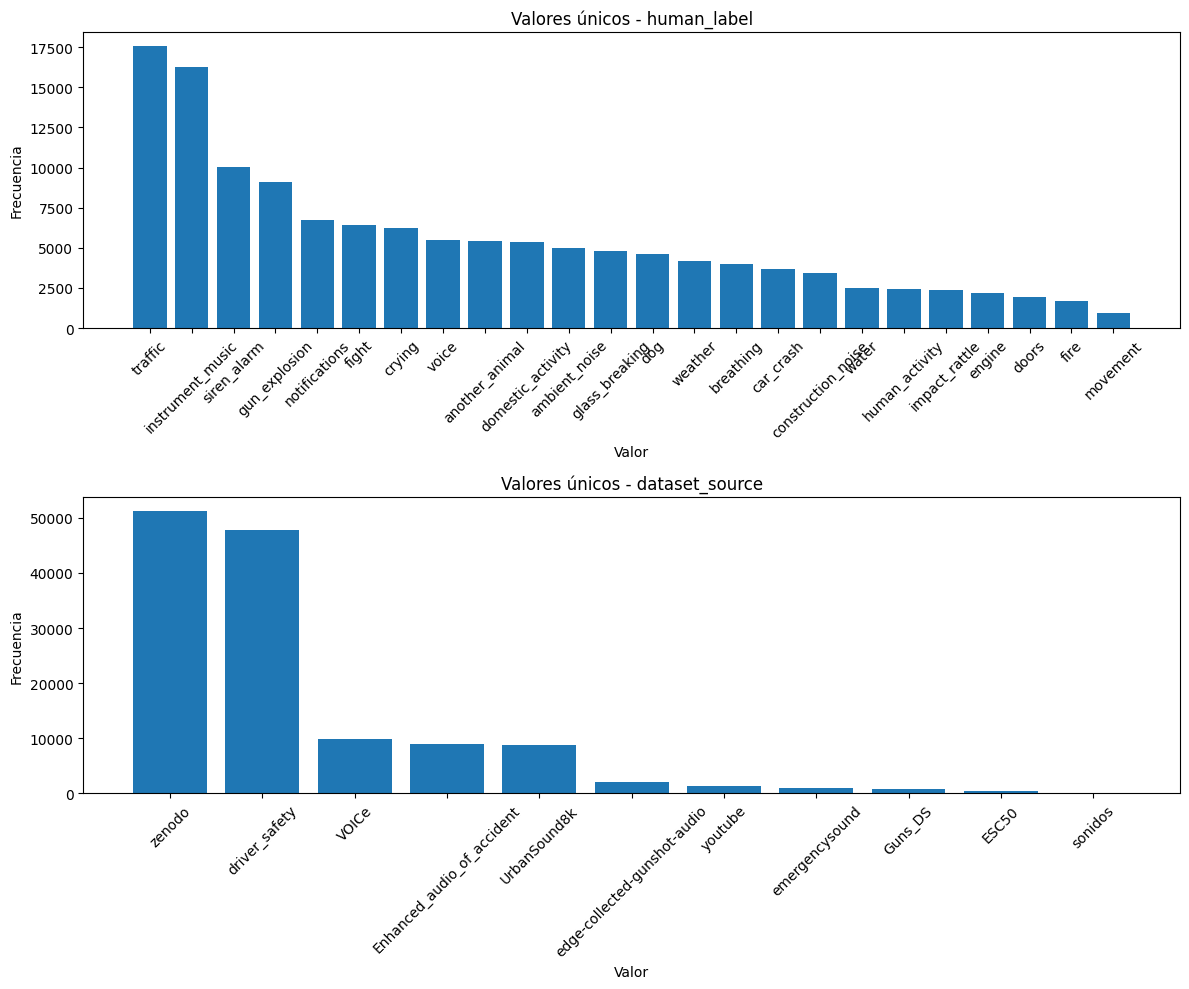

In [9]:
columns_to_plot = [
    "human_label",
    "dataset_source"
]
history_plot(df,columns_to_plot)

In [10]:
df["human_label"].value_counts()

human_label
traffic               17581
instrument_music      16269
siren_alarm           10023
gun_explosion          9104
notifications          6736
fight                  6417
crying                 6219
voice                  5494
another_animal         5444
domestic_activity      5368
ambient_noise          4966
glass_breaking         4811
dog                    4600
weather                4168
breathing              3969
car_crash              3662
construction_noise     3433
water                  2513
human_activity         2440
impact_rattle          2397
engine                 2217
doors                  1939
fire                   1663
movement                946
Name: count, dtype: int64

In [11]:
# ============================
# CONFIGURACIÓN
# ============================
RANDOM_STATE = 42
BALANCE_TEST = True # cambiarlo a True si queremos forzar test balanceado por dataset_source

# ============================
# 1. SEPARAR EN TRAIN / TEST
# ============================
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

# ============================
# 2. DISTRIBUCIÓN REAL EN TRAIN
# ============================
dist = train_df["human_label"].value_counts()

# ============================
# 3. CONFIGURACIÓN DESEADA (totales por clase en train)
# ============================
undersample_target = {
    "traffic": 7600,
    "instrument_music": 7000,
    "siren_alarm": 8000,
}

# Definamos aquí qué clases queremos duplicar y a qué número total apuntar
oversample_target = {
    "engine":3000,
    "doors":2400,
    "movement":1800,
    
}

# ============================
# 4a. AJUSTE AUTOMÁTICO UNDERSAMPLE (no superar lo disponible)
# ============================
for cls, target in list(undersample_target.items()):
    if cls not in dist:
        print(f"Clase no encontrada en train (undersample): {cls}. Se omite.")
        undersample_target.pop(cls)
        continue
    max_allowed = int(dist[cls])
    if target > max_allowed:
        undersample_target[cls] = max_allowed
        print(f"Ajustado undersample {cls}: {target} --> {max_allowed}")

# ============================
# 4b. AJUSTE AUTOMÁTICO OVERSAMPLE (asegurarnos de que pide más de lo que hay)
# ============================
for cls, target in list(oversample_target.items()):
    if cls not in dist:
        print(f"Clase no encontrada en train (oversample): {cls}. Se omite.")
        oversample_target.pop(cls)
        continue
    min_allowed = int(dist[cls])
    if target <= min_allowed:
        oversample_target[cls] = min_allowed
        print(f"Ajustado oversample {cls}: el target ({target}) era menor o igual al original ({min_allowed}). Se deja el original.")

# ============================
# 5. UNDERSAMPLING PROPORCIONAL POR dataset_source EN TRAIN
# ============================
sampled_parts = []
# Excluimos de la base tanto las de undersample como las de oversample para tratarlas por separado
classes_without_target = train_df.loc[
    (~train_df["human_label"].isin(undersample_target)) & 
    (~train_df["human_label"].isin(oversample_target)), :
].copy()

for cls, total_target in undersample_target.items():
    cls_df = train_df[train_df["human_label"] == cls].copy()

    source_counts = cls_df["dataset_source"].value_counts()
    source_proportions = source_counts / source_counts.sum()

    remaining = total_target
    sources = source_proportions.index.tolist()
    for i, src in enumerate(sources):
        if i == len(sources) - 1:
            n = remaining
        else:
            n = round(source_proportions[src] * total_target)
            n = min(n, int(source_counts[src]))
            remaining -= n

        src_cls_df = cls_df[cls_df["dataset_source"] == src]
        n = min(n, len(src_cls_df))
        sampled_parts.append(
            src_cls_df.sample(n=n, random_state=RANDOM_STATE)
        )

# ============================
# 5b. OVERSAMPLING PROPORCIONAL POR dataset_source EN TRAIN (duplicación equitativa)
# ============================
for cls, total_target in oversample_target.items():
    cls_df = train_df[train_df["human_label"] == cls].copy()

    source_counts = cls_df["dataset_source"].value_counts()
    source_proportions = source_counts / source_counts.sum()

    remaining = total_target
    sources = source_proportions.index.tolist()
    for i, src in enumerate(sources):
        if i == len(sources) - 1:
            n = remaining
        else:
            n = round(source_proportions[src] * total_target)
            remaining -= n

        src_cls_df = cls_df[cls_df["dataset_source"] == src]
        
        # Si la proporción pide muestras, pero este subgrupo vino vacío originalmente, saltamos
        if len(src_cls_df) == 0 and n > 0:
            continue
            
        # Activamos 'replace=True' solo si n supera lo que hay en este dataset_source específico
        should_replace = n > len(src_cls_df)
        
        sampled_parts.append(
            src_cls_df.sample(n=n, random_state=RANDOM_STATE, replace=should_replace)
        )

# Unir clases resampleadas (under y over) + clases sin tocar
train_resampled = pd.concat(
    sampled_parts + [classes_without_target], ignore_index=True
).copy()
train_resampled["split"] = "train"

print("\nResampling (Under + Over) proporcional por dataset_source completado:")
print(f"Original train: {len(train_df)} --> Final train: {len(train_resampled)}")
print("\nDistribución train final por human_label:")
print(train_resampled["human_label"].value_counts().sort_index())
print("\nDistribución train final por (dataset_source, human_label):")
print(
    train_resampled.groupby(["dataset_source", "human_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_source", "human_label"])
)

# ============================
# 6. TEST (las condiciones de test se quedan igual)
# ============================
if BALANCE_TEST:
    print("\nBALANCE_TEST=True: balanceando test proporcionalmente por dataset_source.")

    test_class_counts = test_df["human_label"].value_counts()
    min_class_size = int(test_class_counts.min())
    print(f"Tamaño objetivo por clase en test: {min_class_size}")

    test_sampled_parts = []
    for cls in test_class_counts.index:
        cls_df = test_df[test_df["human_label"] == cls].copy()

        source_counts = cls_df["dataset_source"].value_counts()
        source_proportions = source_counts / source_counts.sum()

        remaining = min_class_size
        sources = source_proportions.index.tolist()
        for i, src in enumerate(sources):
            if i == len(sources) - 1:
                n = remaining
            else:
                n = round(source_proportions[src] * min_class_size)
                n = min(n, int(source_counts[src]))
                remaining -= n

            src_cls_df = cls_df[cls_df["dataset_source"] == src]
            n = min(n, len(src_cls_df))
            test_sampled_parts.append(
                src_cls_df.sample(n=n, random_state=RANDOM_STATE)
            )

    test_resampled = pd.concat(test_sampled_parts, ignore_index=True).copy()
else:
    test_resampled = test_df.copy().reset_index(drop=True)

test_resampled["split"] = "test"

# ============================
# 7. CONCATENAR FINAL
# ============================
df_final = pd.concat([train_resampled, test_resampled], ignore_index=True)

print("\nDataFrame final:")
print(f"- Shape: {df_final.shape}")
print(f"- Train: {(df_final['split'] == 'train').sum()}")
print(f"- Test: {(df_final['split'] == 'test').sum()}\n")

print("Distribución final por split, dataset_source y human_label:")
print(
    df_final
    .groupby(["split", "dataset_source", "human_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "dataset_source", "human_label"])
)

# ============================
# 8. GUARDAR
# ============================
df_final.to_csv(RAW_DIR / "dataset_final_resampled.csv", index=False)
print(f"\nGuardado en: {RAW_DIR / 'dataset_final_resampled.csv'}")


Resampling (Under + Over) proporcional por dataset_source completado:
Original train: 109797 --> Final train: 97499

Distribución train final por human_label:
human_label
ambient_noise         4237
another_animal        4570
breathing             3323
car_crash             3048
construction_noise    2718
crying                5182
dog                   3935
domestic_activity     3909
doors                 2400
engine                3000
fight                 5162
fire                  1487
glass_breaking        3829
gun_explosion         7311
human_activity        1994
impact_rattle         1801
instrument_music      7000
movement              1800
notifications         5726
siren_alarm           8000
traffic               7600
voice                 4080
water                 1930
weather               3457
Name: count, dtype: int64

Distribución train final por (dataset_source, human_label):
   dataset_source     human_label  count
0           ESC50       breathing     30
1          

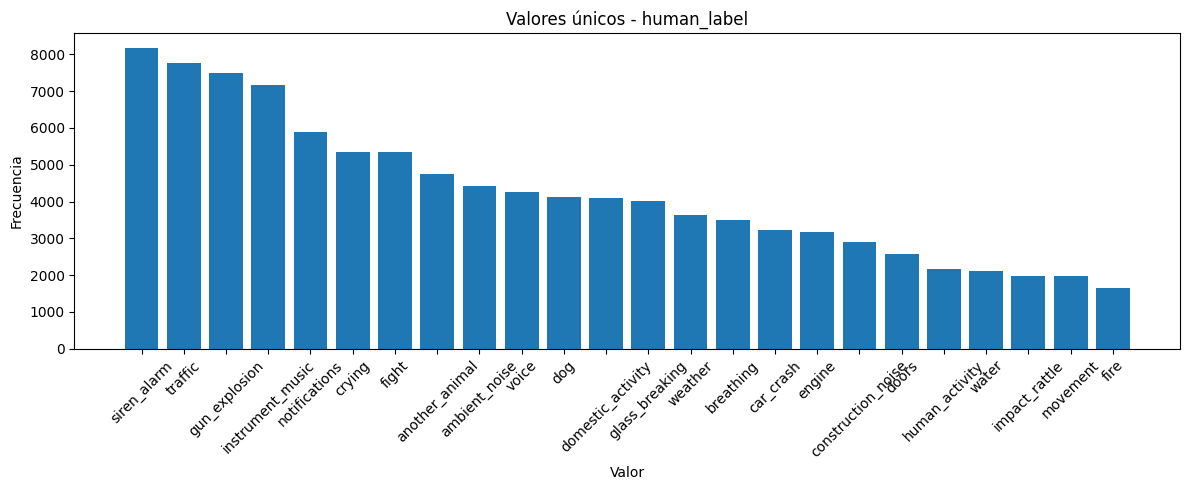

In [12]:
columns_to_plot = [
    "human_label",
]
history_plot(df_final,columns_to_plot)

In [13]:
df_final["alertable"].value_counts()

alertable
False    51691
True     50032
Name: count, dtype: int64

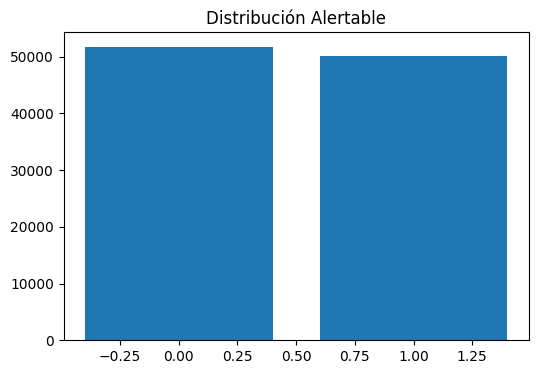

In [14]:
counts = df_final["alertable"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    counts.index,
    counts.values,
)

plt.title("Distribución Alertable")
plt.show()